In [2]:
%pip install --upgrade tensorflow

Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import warnings
import json
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, log_loss, roc_auc_score,
                             f1_score, brier_score_loss, confusion_matrix, mean_absolute_error)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

seed = 123
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

pd.set_option('display.max_columns', None)

# Loading raw data

In [4]:
import zipfile

games_df = pd.read_csv('game_id.csv')

with zipfile.ZipFile('playbyplaydataraw.csv.zip') as z:
    with z.open('playbyplaydataraw.csv') as f:   # targets only the real file
        pbp_df = pd.read_csv(f)

In [5]:
print(f'Dataset size before dropping OT games: {pbp_df.shape}')

# Dropping OT games (any games with more than 4 periods)
ot_games = pbp_df[pbp_df['period'] > 4]['gameId'].unique()
df = pbp_df[~pbp_df['gameId'].isin(ot_games)].copy()
print(f'Dataset size before dropping OT games: {df.shape}')
print(df['gameId'].nunique())

Dataset size before dropping OT games: (1697676, 25)
Dataset size before dropping OT games: (1596513, 25)
3279


In [6]:
df.head()
print(df['shotResult'].value_counts(), "\n")
print(df['actionType'].value_counts())

shotResult
Missed    305123
Made      273937
Name: count, dtype: int64 

actionType
Rebound           336837
Missed Shot       305123
Made Shot         273937
Substitution      154592
Free Throw        145337
Foul              128277
Turnover           91404
Timeout            35395
period             26232
Instant Replay      6367
Violation           5795
Jump Ball           5372
Ejection             225
Name: count, dtype: int64


### actionType definitions

Rebound: Player gains possession after a missed shot (offensive or defensive).

Made Shot: Successful field goal worth 2 or 3 points.

Substitution: A player is replaced by another player during the game.

Free Throw: Uncontested 1-point shot awarded after certain fouls.

Turnover: Loss of possession without a shot attempt (e.g., bad pass, travel).

Jump Ball: Play where the referee tosses the ball between two players to determine possession.

Ejection: Player or coach is removed from the game due to misconduct.

## Feature Engineering

In [ ]:
# Repurposing EDA code from playbyplay_EDA_Extended.ipynb
shots = df[df['isFieldGoal'] == 1].copy()
shots['is_made'] = shots['shotResult'] == 'Made'
shots['points_scored'] = np.where(shots['is_made'], shots['shotValue'], 0)


ft = df[df['actionType'] == 'Free Throw'].copy()
ft['points_scored'] = np.where(ft['shotResult'] == 'Made', 1, 0)

def build_pre_q4_dataset(df, shots, ft):
    """
    All features derived from Q1-Q3 only.
    Q4 data used ONLY to define the outcome (won/lost).
    """

    # --- Points per quarter (Q1-Q4 for outcome, Q1-Q3 for features) ---
    shot_pts = shots.groupby(['gameId','teamId','period'])['points_scored'].sum().reset_index()
    ft_pts   = ft.groupby(['gameId','teamId','period'])['points_scored'].sum().reset_index()
    qtr = (shot_pts
           .merge(ft_pts, on=['gameId','teamId','period'], how='outer',
                  suffixes=('_s','_ft'))
           .fillna(0))
    qtr['total_pts'] = qtr['points_scored_s'] + qtr['points_scored_ft']
    qtr = qtr[qtr['period'].between(1, 4)].copy()

    # --- Non-scoring features: Q1-Q3 only ---
    fg_qtr = (
        shots[shots['period'].between(1, 3)]
        .groupby(['gameId','teamId','period'])
        .apply(lambda x: pd.Series({
            'fg_pct':         x['is_made'].mean(),
            'fg_attempts':    len(x),
            'three_pt_rate':  (x['shotValue'] == 3).mean(),
            'at_rim_rate':    (x['shotDistance'] <= 3).mean(),
            'mid_range_rate': ((x['shotDistance'] > 3) &
                               (x['shotDistance'] < 22)).mean(),
        }), include_groups=False)
        .reset_index()
    )

    tov_qtr = (
        df[(df['actionType'] == 'Turnover') & df['period'].between(1, 3)]
        .groupby(['gameId','teamId','period'])
        .size().reset_index(name='turnovers')
    )

    # --- Pivot points to wide (need Q1-Q4 for outcome) ---
    pts_wide = (
        qtr.pivot_table(index=['gameId','teamId'], columns='period',
                        values='total_pts', aggfunc='sum')
        .rename(columns={1:'pts_Q1',2:'pts_Q2',3:'pts_Q3',4:'pts_Q4'})
        .reset_index()
    )

    # --- Pivot non-scoring features (Q1-Q3 only) ---
    def pivot_feat(df_in, val_col, prefix):
        return (
            df_in.pivot_table(index=['gameId','teamId'], columns='period',
                              values=val_col, aggfunc='mean')
            .rename(columns={1:f'{prefix}_Q1',2:f'{prefix}_Q2',3:f'{prefix}_Q3'})
            .reset_index()
        )

    fg_wide  = pivot_feat(fg_qtr,  'fg_pct',         'fg')
    tpr_wide = pivot_feat(fg_qtr,  'three_pt_rate',  'tpr')
    rim_wide = pivot_feat(fg_qtr,  'at_rim_rate',    'rim')
    mid_wide = pivot_feat(fg_qtr,  'mid_range_rate', 'mid')
    tov_wide = pivot_feat(tov_qtr, 'turnovers',      'tov')

    gt = pts_wide
    for w in [fg_wide, tpr_wide, rim_wide, mid_wide, tov_wide]:
        gt = gt.merge(w, on=['gameId','teamId'], how='left')

    # --- Total points and winner (uses Q4 for outcome only) ---
    gt['total_pts'] = gt[['pts_Q1','pts_Q2','pts_Q3','pts_Q4']].sum(axis=1)
    winners = gt.groupby('gameId')['total_pts'].idxmax()
    gt['won'] = 0
    gt.loc[winners, 'won'] = 1

    # --- Paired game dataset: one row per game, winner vs loser ---
    w = gt[gt['won']==1].add_suffix('_w').rename(columns={'gameId_w':'gameId'})
    l = gt[gt['won']==0].add_suffix('_l').rename(columns={'gameId_l':'gameId'})
    gd = w.merge(l, on='gameId')

    # Cumulative point differential at end of Q1, Q2, Q3 (pre-Q4 only)
    gd['cum_diff_Q1'] = gd['pts_Q1_w'] - gd['pts_Q1_l']
    gd['cum_diff_Q2'] = gd['cum_diff_Q1'] + (gd['pts_Q2_w'] - gd['pts_Q2_l'])
    gd['cum_diff_Q3'] = gd['cum_diff_Q2'] + (gd['pts_Q3_w'] - gd['pts_Q3_l'])

    # Outcome: final margin (uses Q4 — only for target, not features)
    gd['final_margin'] = gd['cum_diff_Q3'] + (gd['pts_Q4_w'] - gd['pts_Q4_l'])

    # Momentum = how cum_diff MOVED during each quarter
    # Positive = winner gained ground that quarter
    # These are all pre-Q4 and knowable before Q4 starts
    gd['momentum_Q1'] = gd['cum_diff_Q1']                          # Q1 swing from 0
    gd['momentum_Q2'] = gd['cum_diff_Q2'] - gd['cum_diff_Q1']      # Q2 swing
    gd['momentum_Q3'] = gd['cum_diff_Q3'] - gd['cum_diff_Q2']      # Q3 swing — key feature

    # Non-scoring differentials (winner minus loser), Q1-Q3 only
    for q in ['Q1','Q2','Q3']:
        gd[f'fg_diff_{q}']  = gd[f'fg_{q}_w']  - gd[f'fg_{q}_l']
        gd[f'tov_diff_{q}'] = gd[f'tov_{q}_w']  - gd[f'tov_{q}_l']
        gd[f'tpr_diff_{q}'] = gd[f'tpr_{q}_w']  - gd[f'tpr_{q}_l']
        gd[f'rim_diff_{q}'] = gd[f'rim_{q}_w']  - gd[f'rim_{q}_l']
        gd[f'mid_diff_{q}'] = gd[f'mid_{q}_w']  - gd[f'mid_{q}_l']

    return gt, gd

game_team, game_diffs = build_pre_q4_dataset(df, shots, ft)
print(f"Pre-Q4 features: Q1, Q2, Q3 only")
print(f"Games in dataset: {len(game_diffs):,}")
print(f"\nAverage final margin: "
      f"{game_diffs['final_margin'].mean():.1f} pts")

Pre-Q4 features: Q1, Q2, Q3 only
Games in dataset: 3,279

Average final margin: 12.8 pts


In [8]:
shot_pts = shots.groupby(['gameId','teamId','period'])['points_scored'].sum().reset_index()
ft_pts   = ft.groupby(['gameId','teamId','period'])['points_scored'].sum().reset_index()
qtr_pts = (shot_pts.merge(ft_pts, on=['gameId','teamId','period'],
                          how='outer', suffixes=('_s','_ft'))
                   .fillna(0))
qtr_pts['pts'] = qtr_pts['points_scored_s'] + qtr_pts['points_scored_ft']
qtr_pts = qtr_pts[qtr_pts['period'].between(1,4)][['gameId','teamId','period','pts']]

# Non-scoring features per quarter (Q1-Q3 only)
fg_q = (shots[shots['period'].between(1,3)]
        .groupby(['gameId','teamId','period'])
        .apply(lambda x: pd.Series({
            'fg_pct': x['is_made'].mean(),
            'tpr':    (x['shotValue'] == 3).mean(),
        }), include_groups=False)
        .reset_index())

tov_q = (df[(df['actionType'] == 'Turnover') & df['period'].between(1,3) & (df['teamId'] != 0)]
         .groupby(['gameId','teamId','period']).size().reset_index(name='tov'))

#Merge all quarter-level features
qtr = (qtr_pts
       .merge(fg_q,  on=['gameId','teamId','period'], how='left')
       .merge(tov_q, on=['gameId','teamId','period'], how='left'))
qtr[['fg_pct','tpr','tov']] = qtr[['fg_pct','tpr','tov']].fillna(0)

# Drop the placeholder teamId == 0 (league-level rows)
qtr = qtr[qtr['teamId'] != 0].copy()
print(qtr.head())
print('Quarter rows:', len(qtr))

     gameId      teamId  period   pts    fg_pct       tpr  tov
0  22200001  1610612738       1  18.0  0.380952  0.428571  4.0
1  22200001  1610612738       2  32.0  0.714286  0.285714  0.0
2  22200001  1610612738       3  27.0  0.571429  0.380952  2.0
3  22200001  1610612738       4  27.0  0.000000  0.000000  0.0
4  22200001  1610612755       1  18.0  0.350000  0.550000  5.0
Quarter rows: 26232


## Building game-level sequence dataset

In [9]:
# For each game, identify the two participating teams and assign as team_A (lower ID) and team_B (higher ID)

team_pairs = (df.loc[df['teamId'] != 0, ['gameId', 'teamId']]
                .drop_duplicates()
                .sort_values(['gameId', 'teamId']))

team_counts = team_pairs.groupby('gameId').size()
valid_games = team_counts[team_counts == 2].index

team_pairs = team_pairs[team_pairs['gameId'].isin(valid_games)].copy()

team_pairs['team_slot'] = team_pairs.groupby('gameId').cumcount()
game_map = (team_pairs.pivot(index='gameId', columns='team_slot', values='teamId')
                     .rename(columns={0: 'team_A_id', 1: 'team_B_id'})
                     .reset_index())

season_map = df[['gameId', 'SEASON']].drop_duplicates('gameId')
game_map = game_map.merge(season_map, on='gameId', how='left')

print(game_map.head())
print('Games with two participating teams identified:', len(game_map))

# pivot quarter features indexed by gameId and teamId
def pivot_q(qtr_df, val_col, prefix, periods=(1, 2, 3, 4)):
    out = (qtr_df.pivot_table(index=['gameId', 'teamId'], columns='period',
                              values=val_col, aggfunc='sum')
                 .reindex(columns=list(periods), fill_value=0)
                 .reset_index())
    out.columns = ['gameId', 'teamId'] + [f'{prefix}_Q{int(c)}' for c in out.columns[2:]]
    return out

pts_w = pivot_q(qtr, 'pts', 'pts')
fg_w  = pivot_q(qtr[qtr['period'].between(1, 3)], 'fg_pct', 'fg', periods=(1, 2, 3))
tpr_w = pivot_q(qtr[qtr['period'].between(1, 3)], 'tpr', 'tpr', periods=(1, 2, 3))
tov_w = pivot_q(qtr[qtr['period'].between(1, 3)], 'tov', 'tov', periods=(1, 2, 3))

team_q = pts_w
for w in (fg_w, tpr_w, tov_w):
    team_q = team_q.merge(w, on=['gameId', 'teamId'], how='left')
team_q = team_q.fillna(0)

team_q = team_q[team_q['gameId'].isin(game_map['gameId'])].copy()

team_q['cum_Q1'] = team_q['pts_Q1']
team_q['cum_Q2'] = team_q['pts_Q1'] + team_q['pts_Q2']
team_q['cum_Q3'] = team_q['pts_Q1'] + team_q['pts_Q2'] + team_q['pts_Q3']
team_q['final_pts'] = team_q['cum_Q3'] + team_q['pts_Q4']

print(team_q.head())
print(team_q.shape)


     gameId   team_A_id   team_B_id   SEASON
0  22200001  1610612738  1610612755  2022-23
1  22200002  1610612744  1610612747  2022-23
2  22200003  1610612753  1610612765  2022-23
3  22200004  1610612754  1610612764  2022-23
4  22200005  1610612737  1610612745  2022-23
Games with two participating teams identified: 3279
     gameId      teamId  pts_Q1  pts_Q2  pts_Q3  pts_Q4     fg_Q1     fg_Q2  \
0  22200001  1610612738    18.0    32.0    27.0    27.0  0.380952  0.714286   
1  22200001  1610612755    18.0    31.0    19.0    25.0  0.350000  0.650000   
2  22200002  1610612744    17.0    30.0    28.0    31.0  0.291667  0.538462   
3  22200002  1610612747    17.0    26.0    15.0    32.0  0.333333  0.444444   
4  22200003  1610612753    24.0    23.0    25.0    23.0  0.578947  0.416667   

      fg_Q3    tpr_Q1    tpr_Q2    tpr_Q3  tov_Q1  tov_Q2  tov_Q3  cum_Q1  \
0  0.571429  0.428571  0.285714  0.380952     4.0     0.0     2.0    18.0   
1  0.473684  0.550000  0.450000  0.315789     5.0

In [10]:
# Join team_A / team_B to get differential features 
team_A = team_q.merge(game_map[['gameId', 'team_A_id', 'SEASON']],
                      left_on=['gameId', 'teamId'],
                      right_on=['gameId', 'team_A_id'],
                      how='inner')

team_B = team_q.merge(game_map[['gameId', 'team_B_id']],
                      left_on=['gameId', 'teamId'],
                      right_on=['gameId', 'team_B_id'],
                      how='inner')

feat_cols = ['pts_Q1', 'pts_Q2', 'pts_Q3', 'cum_Q1', 'cum_Q2', 'cum_Q3',
             'fg_Q1', 'fg_Q2', 'fg_Q3', 'tpr_Q1', 'tpr_Q2', 'tpr_Q3',
             'tov_Q1', 'tov_Q2', 'tov_Q3', 'final_pts']

merged = (team_A[['gameId', 'SEASON'] + feat_cols]
          .merge(team_B[['gameId'] + feat_cols], on='gameId', suffixes=('_A', '_B')))

for q in (1, 2, 3):
    merged[f'pts_diff_Q{q}'] = merged[f'pts_Q{q}_A'] - merged[f'pts_Q{q}_B']
    merged[f'cum_diff_Q{q}'] = merged[f'cum_Q{q}_A'] - merged[f'cum_Q{q}_B']
    merged[f'fg_diff_Q{q}']  = merged[f'fg_Q{q}_A']  - merged[f'fg_Q{q}_B']
    merged[f'tpr_diff_Q{q}'] = merged[f'tpr_Q{q}_A'] - merged[f'tpr_Q{q}_B']
    merged[f'tov_diff_Q{q}'] = merged[f'tov_Q{q}_A'] - merged[f'tov_Q{q}_B']

merged['team_A_win'] = (merged['final_pts_A'] > merged['final_pts_B']).astype(int)

print('Total games:', len(merged))
merged.head()


Total games: 3279


,gameId,SEASON,pts_Q1_A,pts_Q2_A,pts_Q3_A,cum_Q1_A,cum_Q2_A,cum_Q3_A,fg_Q1_A,fg_Q2_A,fg_Q3_A,tpr_Q1_A,tpr_Q2_A,tpr_Q3_A,tov_Q1_A,tov_Q2_A,tov_Q3_A,final_pts_A,pts_Q1_B,pts_Q2_B,pts_Q3_B,cum_Q1_B,cum_Q2_B,cum_Q3_B,fg_Q1_B,fg_Q2_B,fg_Q3_B,tpr_Q1_B,tpr_Q2_B,tpr_Q3_B,tov_Q1_B,tov_Q2_B,tov_Q3_B,final_pts_B,pts_diff_Q1,cum_diff_Q1,fg_diff_Q1,tpr_diff_Q1,tov_diff_Q1,pts_diff_Q2,cum_diff_Q2,fg_diff_Q2,tpr_diff_Q2,tov_diff_Q2,pts_diff_Q3,cum_diff_Q3,fg_diff_Q3,tpr_diff_Q3,tov_diff_Q3,team_A_win
0,22200001,2022-23,18.0,32.0,27.0,18.0,50.0,77.0,0.380952,0.714286,0.571429,0.428571,0.285714,0.380952,4.0,0.0,2.0,104.0,18.0,31.0,19.0,18.0,49.0,68.0,0.350000,0.650000,0.473684,0.550000,0.450000,0.315789,5.0,2.0,5.0,93.0,0.0,0.0,0.030952,-0.121429,-1.0,1.0,1.0,0.064286,-0.164286,-2.0,8.0,9.0,0.097744,0.065163,-3.0,1
1,22200002,2022-23,17.0,30.0,28.0,17.0,47.0,75.0,0.291667,0.538462,0.500000,0.458333,0.346154,0.458333,6.0,2.0,5.0,106.0,17.0,26.0,15.0,17.0,43.0,58.0,0.333333,0.444444,0.285714,0.416667,0.407407,0.476190,6.0,4.0,8.0,90.0,0.0,0.0,-0.041667,0.041667,0.0,4.0,4.0,0.094017,-0.061254,-2.0,13.0,17.0,0.214286,-0.017857,-3.0,1
2,22200003,2022-23,24.0,23.0,25.0,24.0,47.0,72.0,0.578947,0.416667,0.555556,0.421053,0.333333,0.444444,5.0,5.0,6.0,95.0,14.0,31.0,34.0,14.0,45.0,79.0,0.318182,0.650000,0.520000,0.363636,0.450000,0.560000,4.0,2.0,2.0,94.0,10.0,10.0,0.260766,0.057416,1.0,-8.0,2.0,-0.233333,-0.116667,3.0,-9.0,-7.0,0.035556,-0.115556,4.0,1
3,22200004,2022-23,21.0,25.0,20.0,21.0,46.0,66.0,0.347826,0.423077,0.409091,0.608696,0.307692,0.363636,6.0,4.0,2.0,93.0,30.0,20.0,25.0,30.0,50.0,75.0,0.520000,0.375000,0.523810,0.400000,0.291667,0.238095,2.0,4.0,4.0,95.0,-9.0,-9.0,-0.172174,0.208696,4.0,5.0,-4.0,0.048077,0.016026,0.0,-5.0,-9.0,-0.114719,0.125541,-2.0,0
4,22200005,2022-23,22.0,30.0,18.0,22.0,52.0,70.0,0.440000,0.583333,0.421053,0.240000,0.250000,0.368421,2.0,0.0,5.0,97.0,17.0,27.0,26.0,17.0,44.0,70.0,0.380952,0.480000,0.413793,0.285714,0.320000,0.379310,7.0,2.0,1.0,93.0,5.0,5.0,0.059048,-0.045714,-5.0,3.0,8.0,0.103333,-0.070000,-2.0,-8.0,0.0,0.007260,-0.010889,4.0,1


## Data split

In [11]:
# train: 2022-23 + 2023-24
# validation: H1 of 2024-25
# test: H2 of 2024-2025

train_seasons   = ['2022-23', '2023-24']
current_season  = '2024-25'

df_train = merged[merged['SEASON'].isin(train_seasons)].copy()
df_curr  = merged[merged['SEASON'] == current_season].sort_values('gameId').copy()

half = len(df_curr) // 2
df_val  = df_curr.iloc[:half].copy()
df_test = df_curr.iloc[half:].copy()

print(f'Train: {len(df_train)}')
print(f'Validation: {len(df_val)}')
print(f'Test: {len(df_test)}')
print(f'Train teamA rate: {df_train["team_A_win"].mean():.3f}')
print(f'Val teamA rate: {df_val["team_A_win"].mean():.3f}')
print(f'Test teamA rate: {df_test["team_A_win"].mean():.3f}')

Train: 2236
Validation: 521
Test: 522
Train teamA rate: 0.557
Val teamA rate: 0.520
Test teamA rate: 0.527


## Building sequence tensors

In [12]:
# Each game -> becomes a time-series tensor of (3 quarters, F features)
# Standardize using training-set statistics only

feature_groups = {
    'cum' : ['cum_diff_Q{}'],
    'pts' : ['pts_diff_Q{}'],
    'fg' : ['fg_diff_Q{}'],
    'tpr' : ['tpr_diff_Q{}'],
    'tov' : ['tov_diff_Q{}']
}

# loop through quarters and select features for each quarter based on groups
def build_sequences(df, groups, n_quarters):
    feats_per_t = []
    for q in range(1, n_quarters + 1):
        cols = [tmpl.format(q) for grp in groups for tmpl in feature_groups[grp]]
        feats_per_t.append(df[cols].values)
    X = np.stack(feats_per_t, axis=1).astype(np.float32) # stack into a tensor
    y = df['team_A_win'].values.astype(np.float32)
    return X, y

all_groups = ['cum', 'pts', 'fg', 'tpr', 'tov']
X_train, y_train = build_sequences(df_train, all_groups, 3)
X_val,   y_val   = build_sequences(df_val, all_groups, 3)
X_test,  y_test  = build_sequences(df_test, all_groups, 3)
print('Train tensor:', X_train.shape, '-> labels', y_train.shape)
print('Val   tensor:', X_val.shape)
print('Test  tensor:', X_test.shape)

T, F = X_train.shape[1], X_train.shape[2]
scaler = StandardScaler().fit(X_train.reshape(-1, F))

def scale(X):
    return scaler.transform(X.reshape(-1, F)).reshape(-1, T, F).astype(np.float32)

X_train_s = scale(X_train)
X_val_s   = scale(X_val)
X_test_s  = scale(X_test)


Train tensor: (2236, 3, 5) -> labels (2236,)
Val   tensor: (521, 3, 5)
Test  tensor: (522, 3, 5)


## Baseline

In [25]:
# Logistic regression on cum_diff_Q3 only -> identified as most predictive raw_feature based on EDA
# Predicts if team_A wins using only cum_diff_Q3

def evaluate(name, y_true, p_pred, results):
    yhat = (p_pred >= 0.5).astype(int)
    results[name] = {
        'accuracy': accuracy_score(y_true, yhat),
        'auc': roc_auc_score(y_true, p_pred),
        'MAE': mean_absolute_error(y_true, p_pred),
        'log_loss': log_loss(y_true, p_pred, labels=[0,1]),
        'f1': f1_score(y_true, yhat),
    }
    print(f'{name:} acc={results[name]["accuracy"]:.3f}  '
          f'auc={results[name]["auc"]:.3f}  '
          f'logloss={results[name]["log_loss"]:.3f}')

val_results = {}

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(df_train[['cum_diff_Q3']], df_train['team_A_win'])
p_log_reg_val = log_reg.predict_proba(df_val[['cum_diff_Q3']])[:, 1]
evaluate('Logistic regression (cum_diff_Q3 only):', y_val, p_log_reg_val, val_results)

Logistic regression (cum_diff_Q3 only): acc=0.829  auc=0.918  logloss=0.365


In [26]:
from sklearn.ensemble import GradientBoostingClassifier
X_train_flat = X_train_s.reshape(len(X_train_s), -1)
X_val_flat   = X_val_s.reshape(len(X_val_s), -1)
X_test_flat  = X_test_s.reshape(len(X_test_s), -1)

gbm = GradientBoostingClassifier(n_estimators=400, max_depth=3,learning_rate=0.05, random_state=seed)

gbm.fit(X_train_flat, y_train)
p_gbm_val = gbm.predict_proba(X_val_flat)[:, 1]
evaluate('GBM (flattened sequence):', y_val, p_gbm_val, val_results)

GBM (flattened sequence): acc=0.810  auc=0.904  logloss=0.407


# Time-aware GRU model

In [27]:
# Input: (batch, 3, 5) - three quarter vectors of 5 differential features
# Unidirectional GRU - to preserve causual order of Q1 to Q3
# L2 regularization 
# Output: predicts if team_A in the game wins

def build_gru(input_shape, hidden=32, dense=16, dropout=0.3, l2=1e-4):
    inp = layers.Input(shape=input_shape, name='quarter_seq')
    x = layers.GRU(hidden, return_sequences=False,
                   kernel_regularizer=regularizers.l2(l2),
                   recurrent_regularizer=regularizers.l2(l2))(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out, name='gru_qsequence')
    model.compile(optimizer=tf.keras.optimizers.Adam(),loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

gru_model = build_gru(X_train_s.shape[1:])
gru_model.summary()

Model: "gru_qsequence"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ quarter_seq (InputLayer)        │ (None, 3, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = gru_model.fit(X_train_s, y_train,
                        validation_data=(X_val_s, y_val),
                        epochs=20,
                        batch_size=32,
                        callbacks=[
                            tf.keras.callbacks.EarlyStopping(
                                monitor='val_loss',
                                patience=5,
                                restore_best_weights=True
                            )
                        ],
                        verbose=1
                        )

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7469 - auc: 0.8430 - loss: 0.5569 - val_accuracy: 0.8292 - val_auc: 0.9078 - val_loss: 0.4227
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8354 - auc: 0.9043 - loss: 0.4044 - val_accuracy: 0.8234 - val_auc: 0.9085 - val_loss: 0.3876
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8430 - auc: 0.9112 - loss: 0.3799 - val_accuracy: 0.8388 - val_auc: 0.9136 - val_loss: 0.3791
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8453 - auc: 0.9111 - loss: 0.3799 - val_accuracy: 0.8369 - val_auc: 0.9155 - val_loss: 0.3751
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8453 - auc: 0.9129 - loss: 0.3755 - val_accuracy: 0.8349 - val_auc: 0.9163 - val_loss: 0.3747
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8484 - auc: 0.9144 - loss: 0.3746 - val_accuracy: 0.8349 - val_auc: 0.9166 - val_loss: 0.3752
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step -

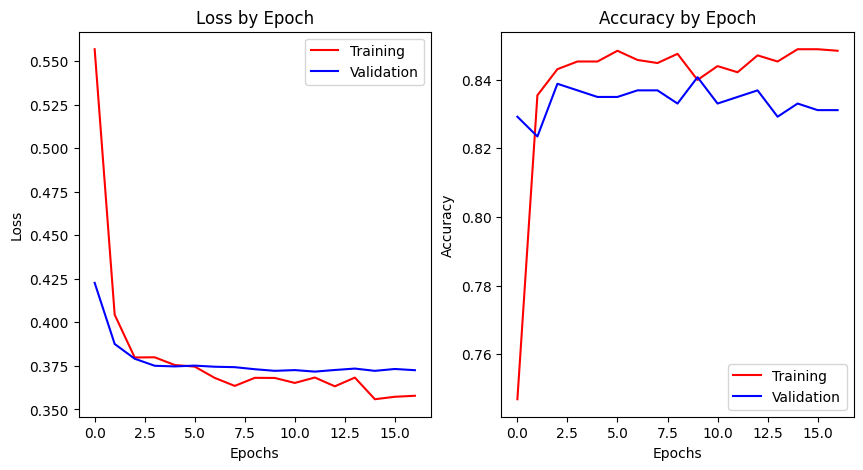

In [29]:
gru_model.history.history
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(gru_model.history.history['loss'], color='r', label='Training')
ax[0].plot(gru_model.history.history['val_loss'], color='b', label='Validation')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss by Epoch')
ax[0].legend()

ax[1].plot(gru_model.history.history['accuracy'], color='r', label='Training')
ax[1].plot(gru_model.history.history['val_accuracy'], color='b', label='Validation')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Accuracy by Epoch')
ax[1].legend()


* Untuned GRU model is does now show an improvement over LogReg baseline model only using Q3 -> learning team leading late wins
* Sequential quarter to quarter dynamics limit predictive value
* Late game state captures most of the predictive signals needed for a win prediction

## Hyperparameter tuning on validation set

In [30]:
def fit_one(hp, verbose=0):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed); np.random.seed(seed)
    model = build_gru(X_train_s.shape[1:],
                      hidden=hp['hidden'], dense=hp['dense'],
                      dropout=hp['dropout'], l2=hp['l2'])
    es = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                 restore_best_weights=True, verbose=0)
    hist = model.fit(X_train_s, y_train,
                     validation_data=(X_val_s, y_val),
                     epochs=120, batch_size=hp['batch'],
                     callbacks=[es], verbose=verbose)
    p_val = model.predict(X_val_s, verbose=0).ravel()
    return model, hist, p_val

grid = [
    dict(hidden=h, dense=16, dropout=d, l2=1e-4, lr=lr_, batch=64)
    for h in (16, 32, 64)
    for d in (0.2, 0.4)
    for lr_ in (1e-3, 5e-4)
]

tune_log = []
best = {'val_logloss': np.inf}
for i, hp in enumerate(grid):
    _, _, p_val = fit_one(hp)
    ll = log_loss(y_val, p_val, labels=[0,1])
    auc = roc_auc_score(y_val, p_val)
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))
    tune_log.append({**hp, 'val_logloss': ll, 'val_auc': auc, 'val_acc': acc})
    print(f'[{i+1:>2}/{len(grid)}] {hp}  ->  '
          f'val_logloss={ll:.4f}  val_auc={auc:.4f}  val_acc={acc:.4f}')
    if ll < best['val_logloss']:
        best = {**hp, 'val_logloss': ll, 'val_auc': auc, 'val_acc': acc}

tune_df = pd.DataFrame(tune_log).sort_values('val_logloss')
print('\nTop 5 configs:')
print(tune_df.head().to_string(index=False))
print('\nBest config:', best)

[ 1/12] {'hidden': 16, 'dense': 16, 'dropout': 0.2, 'l2': 0.0001, 'lr': 0.001, 'batch': 64}  ->  val_logloss=0.3683  val_auc=0.9161  val_acc=0.8292
[ 2/12] {'hidden': 16, 'dense': 16, 'dropout': 0.2, 'l2': 0.0001, 'lr': 0.0005, 'batch': 64}  ->  val_logloss=0.3649  val_auc=0.9179  val_acc=0.8369
[ 3/12] {'hidden': 16, 'dense': 16, 'dropout': 0.4, 'l2': 0.0001, 'lr': 0.001, 'batch': 64}  ->  val_logloss=0.3642  val_auc=0.9167  val_acc=0.8330
[ 4/12] {'hidden': 16, 'dense': 16, 'dropout': 0.4, 'l2': 0.0001, 'lr': 0.0005, 'batch': 64}  ->  val_logloss=0.3663  val_auc=0.9167  val_acc=0.8349
[ 5/12] {'hidden': 32, 'dense': 16, 'dropout': 0.2, 'l2': 0.0001, 'lr': 0.001, 'batch': 64}  ->  val_logloss=0.3681  val_auc=0.9166  val_acc=0.8292
[ 6/12] {'hidden': 32, 'dense': 16, 'dropout': 0.2, 'l2': 0.0001, 'lr': 0.0005, 'batch': 64}  ->  val_logloss=0.3686  val_auc=0.9160  val_acc=0.8330
[ 7/12] {'hidden': 32, 'dense': 16, 'dropout': 0.4, 'l2': 0.0001, 'lr': 0.001, 'batch': 64}  ->  val_logloss=

GRU (best, val) acc=0.831  auc=0.917  logloss=0.367


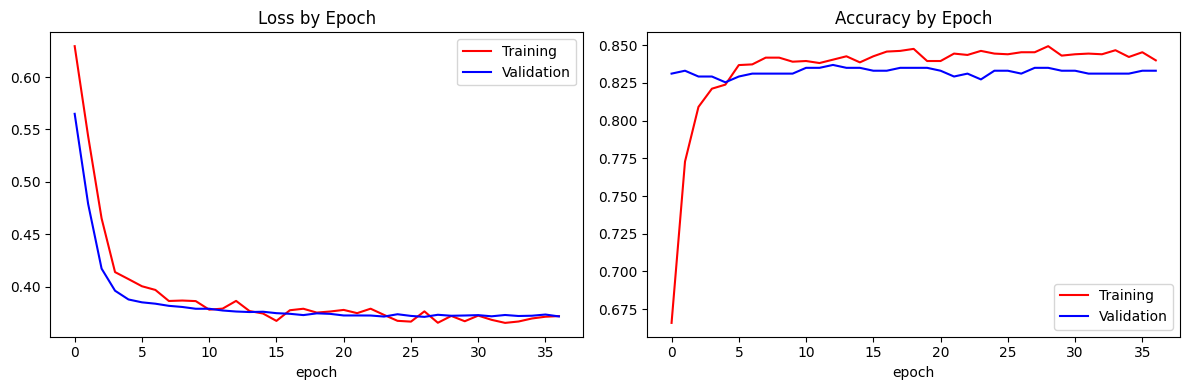


Validation comparison:


,accuracy,auc,MAE,log_loss,f1
Logistic regression (cum_diff_Q3 only):,0.8292,0.9176,0.2217,0.3653,0.8414
GBM (flattened sequence):,0.8100,0.9041,0.2256,0.4070,0.8203
"GRU (best, val)",0.8311,0.9169,0.2234,0.3671,0.8412


In [31]:
# Refit best config and record validation performance for the comparison table
best_hp = {k: best[k] for k in ('hidden','dense','dropout','l2','lr','batch')}
best_model, best_hist, p_gru_val = fit_one(best_hp, verbose=0)
evaluate('GRU (best, val)', y_val, p_gru_val, val_results)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(best_hist.history['loss'],color='r',label='Training')
ax[0].plot(best_hist.history['val_loss'],color='b',label='Validation')
ax[0].set_title('Loss by Epoch')
ax[0].set_xlabel('epoch')
ax[0].legend()

ax[1].plot(best_hist.history['accuracy'],color='r',label='Training')
ax[1].plot(best_hist.history['val_accuracy'],color='b',label='Validation')
ax[1].set_title('Accuracy by Epoch')
ax[1].set_xlabel('epoch')
ax[1].legend()
plt.tight_layout()
plt.show()

print('\nValidation comparison:')
pd.DataFrame(val_results).T.round(4)

## Test set evaluation

LogReg (cum_diff_Q3 only) acc=0.818  auc=0.905  logloss=0.393
GBM (flattened sequence) acc=0.807  auc=0.891  logloss=0.438
GRU (best) acc=0.820  auc=0.904  logloss=0.395
                           accuracy     auc     MAE  log_loss      f1
LogReg (cum_diff_Q3 only)    0.8180  0.9046  0.2330    0.3928  0.8319
GBM (flattened sequence)     0.8065  0.8909  0.2345    0.4381  0.8200
GRU (best)                   0.8199  0.9040  0.2334    0.3955  0.8333


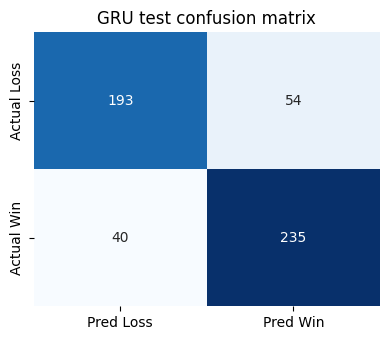

In [32]:
test_results = {}

p_lr_test  = log_reg.predict_proba(df_test[['cum_diff_Q3']])[:, 1]
evaluate('LogReg (cum_diff_Q3 only)', y_test, p_lr_test, test_results)

p_gbm_test = gbm.predict_proba(X_test_flat)[:, 1]
evaluate('GBM (flattened sequence)', y_test, p_gbm_test, test_results)

p_gru_test = best_model.predict(X_test_s, verbose=0).ravel()
evaluate('GRU (best)', y_test, p_gru_test, test_results)

test_df = pd.DataFrame(test_results).T.round(4)
print(test_df)

# Confusion matrix for the GRU
cm = confusion_matrix(y_test, (p_gru_test >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Loss','Pred Win'], yticklabels=['Actual Loss','Actual Win'], ax=ax)
ax.set_title('GRU test confusion matrix'); plt.tight_layout(); plt.show()

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
diff_bucket
0-3      0.611765
4-6      0.691358
7-10     0.785714
11-15    0.923077
>15      0.975758
Name: correct, dtype: float64
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/var/folders/r0/bv3cbzp53d352ym6h2rfx8680000gn/T/ipykernel_782/3452654905.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_acc = df_eval.groupby('diff_bucket')['correct'].mean()
/var/folders/r0/bv3cbzp53d352ym6h2rfx8680000gn/T/ipykernel_782/3452654905.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = df_eval.groupby('bin').agg({


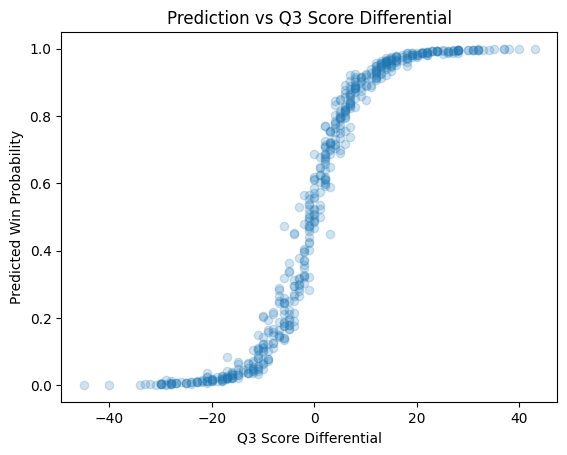

In [33]:
df_eval = df_test.copy()
df_eval['pred'] = (gru_model.predict(X_test_s).flatten() > 0.5).astype(int)
df_eval['correct'] = (df_eval['pred'] == y_test).astype(int)

# bucket by absolute score diff
bins = [0, 3, 6, 10, 15, 100]
labels = ['0-3', '4-6', '7-10', '11-15', '>15']
df_eval['diff_bucket'] = pd.cut(df_eval['cum_diff_Q3'].abs(), bins=bins, labels=labels)

bucket_acc = df_eval.groupby('diff_bucket')['correct'].mean()
print(bucket_acc)

df_eval['prob'] = gru_model.predict(X_test_s).flatten()

df_eval['bin'] = pd.qcut(df_eval['prob'], 10, duplicates='drop')

calibration = df_eval.groupby('bin').agg({
    'prob': 'mean',
    'team_A_win': 'mean'
})
plt.scatter(df_eval['cum_diff_Q3'], df_eval['prob'], alpha=0.2)
plt.xlabel('Q3 Score Differential')
plt.ylabel('Predicted Win Probability')
plt.title('Prediction vs Q3 Score Differential')
plt.show()